In [2]:
#impots


In [61]:
from scipy.sparse import coo_matrix
import numpy as np

def generate_graph(total_population, number_nodes, area):
    rank = np.arange(1, number_nodes + 1)
    population_dist = 1 / rank #zipfs law fore reaslitc cities

    population = (population_dist / population_dist.sum()) * total_population
    population= population.astype(int)
    population[0] += total_population - population.sum() #for integer rounding errors

    side_length = np.sqrt(area)
    positions = np.random.rand(number_nodes, 2) * side_length

    rows,cols, weights = [], [], []

    for i in range(number_nodes):
        distances = np.sqrt(((positions[i] - positions) ** 2).sum(axis=1))
        distances[i] = np.inf
        distances[distances == 0] = 0.1

        #attraction = g * (m * m) / d^2
        flow = (population[i] * population) / (distances ** 2)
        flow[i] = 0
        flow = np.asarray(flow).flatten()
        # print(type(flow))
        # print(np.shape(flow))

        # # only keeo flows above threshold
        # threshold = np.percentile(flow [flow > 0], 90) #threshol is 10% most attractive cities
        # desitnations_index = np.where(flow > threshold)[0]
        #
        k = np.random.randint(10, 30)
        desitnations_index = np.argsort(flow)[-k:]

        for j in desitnations_index:
            rows.append(i)
            cols.append(j)
            weights.append(flow[j])
        #print(flow)

    rows = np.array(rows)
    cols = np.array(cols)
    weights = np.array(weights)

    #print(weights)


    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    weights = weights / row_sums[rows] #normalis weights
    #print(weights)

    #create graph
    graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
    graph = graph.tocsr()

    return graph, population


In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def visualise_graph(graph):
    graph = nx.from_scipy_sparse_array(graph)

    # threshold = 0.5  # Example threshold
    # elarge = [(u, v) for (u, v, d) in graph.edges(data=True) if d["weight"] > threshold]

    # 3. Draw
    pos = nx.spring_layout(graph, seed=42)  # Positions for all nodes
    nx.draw_networkx_nodes(graph, pos, node_size=10)
    nx.draw_networkx_edges(graph, pos, width=0.1, alpha=0.5)

    plt.title("Flow Graph (Filtered)")
    plt.show()



In [59]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3



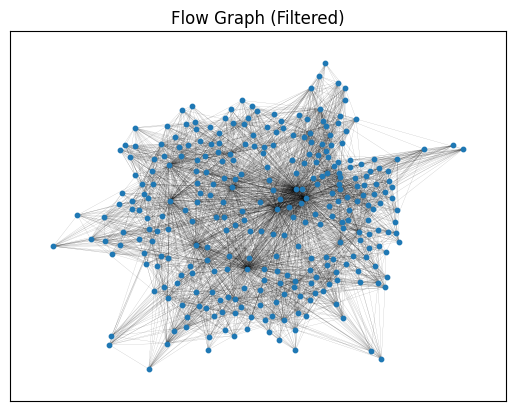

1.8291731488836274
0.5466951013414534


In [64]:
from scipy.linalg import eig

def generate_data(total_population,total_area,number_nodes, recovery_rate, mobility_rate = 1 ):
    graph,population = generate_graph(total_population, number_nodes, total_area)
    visualise_graph(graph)

        #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()

    #devide area acording to log-linear dist
    log_population = np.log1p(population)
    area_distr = (log_population/np.sum(log_population)) * total_area


    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))

    # matrix_m_2 = calculte_m(area_distr, eff_population, graph, 0)
    #
    # eigenvalues_2, _ = eigs(matrix_m_2, k=1, which='LM')
    # spectral_radius_2 = np.abs(eigenvalues_2[0])

    print(spectral_radius)
    # print(spectral_radius_2)



    print(recovery_rate / spectral_radius)
    # print(recovery_rate / spectral_radius_2)

    # print(spectral_radius / spectral_radius_2)

    # print(eff_population)
    # print(area_distr)
    # print()

generate_data(5557233, 12300, 300, 1, 1)
